#  A Brain Tumor MRI Classification Model  Using Custom CNN with Integrated Gradients Interpretability
## with De-duplication, Higher Resolution, Class Weights & Integrated Gradients

This project presents a brain tumor MRI classification system that identifies four classes: glioma, meningioma, no tumor, and pituitary tumor. The goal of the project is to demonstrate how deep learning can be used to support medical image classification by automatically learning patterns from MRI scans. In addition, the project includes an explainability component that uses Integrated Gradients to highlight the regions of the MRI image that most influenced the model’s prediction. This makes the system more transparent and easier to interpret, especially in a medical context where understanding why a prediction was made is just as important as the prediction itself.

## 0. Imports

In [1]:
import os
import gc
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-05-28 19:23:31.883731: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779996212.076822      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779996212.135435      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779996212.609979      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779996212.610016      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779996212.610019      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 1. Config

In [2]:
BASE_DATA_DIR = '/kaggle/input/datasets/fatmaraafatelshaer/brain-tumor-dataset/brain-tumor-mri-dataset'
MODEL_SAVE    = '/kaggle/working/best_custom_cnn_improved.keras'
CLASS_NAMES   = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES   = len(CLASS_NAMES)

IMG_SIZE = (160, 160)
BATCH_SIZE = 16
EPOCHS = 40

## 2. Preprocessing Function

In [3]:
# Defined for usage in the Web App.
# Takes image (pixels) as an input.
def preprocess_brain_mri_array(img, target_size=IMG_SIZE):
    
    if img is None:
        return None
    # Force grayscale regardless of how the image arrived (color uploads included).
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    rgb_img = cv2.cvtColor(resized, cv2.COLOR_GRAY2BGR)
    return rgb_img

# Defined for the usage in image preprocessing for the model.
# Takes image file path as an input.
def preprocess_brain_mri(image_path, target_size=IMG_SIZE):
    
    img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        return None

    resized = cv2.resize(img_gray, target_size, interpolation=cv2.INTER_AREA)

    rgb_img = cv2.cvtColor(resized, cv2.COLOR_GRAY2BGR)
    return rgb_img  # range [0, 255]

## 3. Build dataset arrays

In [4]:
print("\nLoading dataset...")
X_list, y_list = [], []

for class_idx, class_name in enumerate(CLASS_NAMES):
    # Build path to class folder
    class_path   = os.path.join(BASE_DATA_DIR, class_name)
    
    # Get all image files sorted within their specific class.
    # If the code is ran again, the images will be in the same order
    image_files  = sorted(f for f in os.listdir(class_path)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')))
    print(f"  {class_name}: {len(image_files)} images")

    # Preprossing the images
    for i, fname in enumerate(image_files):
        img = preprocess_brain_mri(os.path.join(class_path, fname))

        # Storing valid images and labels
        if img is not None:
            X_list.append(img)
            y_list.append(class_idx)

# Convert to NumPy arrays. dtype=uint8 keeps memory usage minimal.
# If float32 is used, 4× more RAM for the same data.

X_full = np.array(X_list, dtype=np.uint8)
y_full = np.array(y_list)

print(f"\nDataset: {X_full.shape} | Labels: {y_full.shape}")


Loading dataset...
  glioma: 1621 images
  meningioma: 1775 images
  notumor: 2000 images
  pituitary: 1757 images

Dataset: (7153, 160, 160, 3) | Labels: (7153,)


## 3.5 De-duplication (removes the data leakage)

The public brain-tumor MRI dataset contains many near-identical slices.
If two near-duplicates land on opposite sides of the train/test split, the model "passes"
the test by recognizing an image almost identical to one it trained on — that's the leakage

We compute a small **perceptual hash (average hash)** for every image: downscale to 8×8,
compare each pixel to the mean, and pack the 64 booleans into a single 64-bit integer.
Images whose hashes are identical are treated as duplicates and all but one are dropped.

In [5]:
# Perceptual Hash Function
def average_hash(img, hash_size=8):
   
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img
    small = cv2.resize(gray, (hash_size, hash_size), interpolation=cv2.INTER_AREA)

    # Comparing each pixel to the mean
    bits  = (small > small.mean()).flatten() # The output will be an array of True or False

    # Converting the array of true or false into integers / zeroz and ones
    h = 0
    for b in bits:
        h = (h << 1) | int(b)
    return h

# Removes duplicate and near-duplicate images from the dataset by:
# keeping only the first occurrence of each unique perceptual hash.
print("Computing perceptual hashes for de-duplication...")
seen   = set()                               # Empty set to store unique hashes
keep   = np.zeros(len(X_full), dtype=bool)   # All images (all False initially)

for i in range(len(X_full)): 

    # creating fingerprint for each image
    h = average_hash(X_full[i])

    # Checking for duplicates
    if h not in seen:
        seen.add(h)
        keep[i] = True

n_before = len(X_full)
X_full = X_full[keep]
y_full = y_full[keep]
n_after = len(X_full)
print(f"Removed {n_before - n_after} duplicate/near-duplicate images "
      f"({n_before} -> {n_after}).")

# Report how many remain per class so we can see if any class was hit hard.
for class_idx, class_name in enumerate(CLASS_NAMES):
    print(f"  {class_name}: {(y_full == class_idx).sum()} images after de-dup")

gc.collect()

Computing perceptual hashes for de-duplication...
Removed 3814 duplicate/near-duplicate images (7153 -> 3339).
  glioma: 952 images after de-dup
  meningioma: 864 images after de-dup
  notumor: 517 images after de-dup
  pituitary: 1006 images after de-dup


0

## 4. Train / Val / Test split

70% Train, 15% Validation, 15% Test, stratified by class. The de-duplication above means no near-duplicate can straddle the split, so this score is honest.

In [6]:
y_one_hot = to_categorical(y_full, num_classes=NUM_CLASSES) # e.g., class 2 (notumor) becomes [0, 0, 1, 0]


# 70% train, 30% validation and test
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X_full, y_one_hot,
    test_size=0.30,
    random_state=42,
    stratify=y_full # insures that each class is split in a balanced way
)

# Separating the validation and testset in half
X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test,
    test_size=0.50,
    random_state=42,
    stratify=np.argmax(y_val_test, axis=1)  # convert back to int for stratify
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 2337 | Val: 501 | Test: 501


## 5.1 Data Augmentation

In [7]:
NUM_AUGMENTATIONS_PER_IMAGE = 5
print(f"Generating {NUM_AUGMENTATIONS_PER_IMAGE} augmented images for each training sample...")

# Applying different augmentations 
offline_augmenter = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.20,
    brightness_range=(0.85, 1.15),
    horizontal_flip=True,
    fill_mode='nearest'
)

total_samples = len(X_train) * (1 + NUM_AUGMENTATIONS_PER_IMAGE)
X_train_augmented = np.empty((total_samples, *X_train.shape[1:]), dtype=np.uint8)
y_train_augmented = np.empty((total_samples, *y_train.shape[1:]), dtype=y_train.dtype)

# Iterate through the original training data and generate augmented samples
write_idx = 0
for original_img, original_label in zip(X_train, y_train):
    # Add the original image to the augmented array as well
    X_train_augmented[write_idx] = original_img
    y_train_augmented[write_idx] = original_label
    write_idx += 1

    for _ in range(NUM_AUGMENTATIONS_PER_IMAGE):
        
        # random_transform expects float input; cast back to uint8 after
        aug_img = offline_augmenter.random_transform(original_img.astype('float32'))
        X_train_augmented[write_idx] = np.clip(aug_img, 0, 255).astype(np.uint8)
        y_train_augmented[write_idx] = original_label
        write_idx += 1

print(f"Original training samples: {len(X_train)}")
print(f"Number of augmented copies per image: {NUM_AUGMENTATIONS_PER_IMAGE}")
print(f"Total training samples after augmentation (original + augmented): {len(X_train_augmented)}")


X_train = X_train_augmented
y_train = y_train_augmented
print(f"X_train{X_train.shape} and y_train{y_train.shape} have been updated with augmented data.")

del X_train_augmented, y_train_augmented
gc.collect()

Generating 5 augmented images for each training sample...
Original training samples: 2337
Number of augmented copies per image: 5
Total training samples after augmentation (original + augmented): 14022
X_train(14022, 160, 160, 3) and y_train(14022, 4) have been updated with augmented data.


0

## 5. Data generators (Augmentation)

In [8]:
def make_generators():

    # Creating training data generator
    train_datagen = ImageDataGenerator()  # No augmentation

    # Creating validation data generator
    val_datagen   = ImageDataGenerator()  # No augmentation

    # Shuffling training data only
    tgen = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
    vgen = val_datagen.flow(X_val,   y_val,   batch_size=BATCH_SIZE, shuffle=False)
    return tgen, vgen

## 5.5 Class weights

Meningioma is the class most often confused with glioma. Class weights tell the loss
function to penalize mistakes on under-represented / harder classes more heavily, nudging
the model to stop sacrificing the weak class for overall accuracy. We compute weights
inversely proportional to class frequency from the (pre-augmentation) training labels.

In [9]:
# Computing weight as the classes are unbalanced
# Higher weight means more penality for mistakes

from sklearn.utils.class_weight import compute_class_weight

y_train_int = np.argmax(y_train, axis=1)
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train_int
)
class_weight = {i: float(w) for i, w in enumerate(weights)}
print("Class weights (higher = model cares more about this class):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {class_weight[i]:.3f}")

Class weights (higher = model cares more about this class):
  glioma: 0.877
  meningioma: 0.966
  notumor: 1.614
  pituitary: 0.830


## 6. Build Model

In [10]:
import tensorflow.keras.regularizers as regularizers

def build_custom_cnn(input_shape=(160, 160, 3), num_classes=4):
    
    inputs = tf.keras.Input(shape=input_shape)

    # Normalization — handles the [0,255] → [0,1] conversion inside the model
    x = layers.Rescaling(1./255)(inputs)

    # ── Block 1: 32 filters ──────────────────────────────
    
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)   # 128 → 64
    x = layers.Dropout(0.30)(x)

    # ── Block 2: 64 filters ──────────────────────────────
    
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)   # 64 → 32
    x = layers.Dropout(0.35)(x)

    # ── Block 3: 128 filters ─────────────────────────────

    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)   # 32 → 16
    x = layers.Dropout(0.40)(x)

    # ── Block 4: 256 filters ─────────────────────────────
    
    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)   # 16 → 8
    x = layers.Dropout(0.45)(x)

    # ── Head ─────────────────────────────────────────────
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256,
                     activation='relu',
                     kernel_regularizer=regularizers.l2(2e-3))(x)
    
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.6)(x)

    # Using softmax for classification
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return tf.keras.Model(inputs, outputs)


model = build_custom_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=NUM_CLASSES)
model.summary()

# Quick parameter count check
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\nTotal trainable parameters: {trainable_params:,}")
# ~1.24M — roughly 3.5× fewer than EfficientNetB0 (4.4M)
print("(EfficientNetB0 had 4,379,559 — this model is intentionally lighter)")


I0000 00:00:1779996338.821506      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779996338.827499      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 80, 80, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 40, 40, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,243,940 (4.75 MB)

 Trainable params: 1,241,508 (4.74 MB)

 Non-trainable params: 2,432 (9.50 KB)


Total trainable parameters: 1,241,508
(EfficientNetB0 had 4,379,559 — this model is intentionally lighter)


## 7. Compile

In [11]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', # Used when labels are one-hot encoded
    metrics=['accuracy']
)

## 8. Callbacks

In [12]:
callbacks = [
    ModelCheckpoint(
        MODEL_SAVE,
        monitor='val_accuracy',  # an honest signal of generalization
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(  #Stops when validation accuracy plateaus
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,  # roll back to the best epoch, not the last
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,   # Waits 4 epochs before reducing the learning rate by half
        min_lr=1e-7,
        verbose=1
    ),
]

## 9. Train

In [13]:
print("\n── Training the model ──")
train_gen, val_gen = make_generators()

history = model.fit(
    train_gen,
    
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    
    validation_data=val_gen,
    validation_steps=None,  # run the full validation set every epoch
    
    callbacks=callbacks,
    class_weight=class_weight  
)

print(f"\nBest val_accuracy: {max(history.history['val_accuracy']):.4f}")


── Training the model ──
Epoch 1/40


I0000 00:00:1779996346.951456     128 service.cc:152] XLA service 0x78517808f8c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779996346.951500     128 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779996346.951504     128 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779996348.042827     128 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-28 19:25:51.419468: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 19:25:51.569017: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 19:25:52.711704: E external/local_xl

  2/876 ━━━━━━━━━━━━━━━━━━━━ 57s 66ms/step - accuracy: 0.2812 - loss: 2.4940   

I0000 00:00:1779996360.352606     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


526/876 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - accuracy: 0.5023 - loss: 1.6971

2026-05-28 19:26:25.220720: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 19:26:25.367864: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 19:26:25.617977: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 19:26:25.760738: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 19:26:26.391072: E external/local_xla/xla/stream_

876/876 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5229 - loss: 1.5954
Epoch 1: val_accuracy improved from None to 0.55689, saving model to /kaggle/working/best_custom_cnn_improved.keras

Epoch 1: finished saving model to /kaggle/working/best_custom_cnn_improved.keras
876/876 ━━━━━━━━━━━━━━━━━━━━ 71s 60ms/step - accuracy: 0.5684 - loss: 1.3763 - val_accuracy: 0.5569 - val_loss: 1.1995 - learning_rate: 0.0010
Epoch 2/40
  1/876 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.3125 - loss: 1.8606

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.55689 to 0.55888, saving model to /kaggle/working/best_custom_cnn_improved.keras

Epoch 2: finished saving model to /kaggle/working/best_custom_cnn_improved.keras
876/876 ━━━━━━━━━━━━━━━━━━━━ 1s 759us/step - accuracy: 0.3125 - loss: 1.8606 - val_accuracy: 0.5589 - val_loss: 1.1659 - learning_rate: 0.0010
Epoch 3/40
875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6669 - loss: 0.9867
Epoch 3: val_accuracy did not improve from 0.55888
876/876 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - accuracy: 0.7013 - loss: 0.8915 - val_accuracy: 0.3054 - val_loss: 2.5606 - learning_rate: 0.0010
Epoch 4/40
  1/876 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - accuracy: 0.8750 - loss: 0.4385
Epoch 4: val_accuracy did not improve from 0.55888
876/876 ━━━━━━━━━━━━━━━━━━━━ 1s 545us/step - accuracy: 0.8750 - loss: 0.4385 - val_accuracy: 0.2535 - val_loss: 3.0705 - learning_rate: 0.0010
Epoch 5/40
875/876 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7677 - loss: 0.7001
Epoch

## 10. Test Set Evaluation

In [14]:
# Testing the model
print("\n── Test set evaluation ──")
test_gen = ImageDataGenerator().flow(X_test, y_test, batch_size=BATCH_SIZE, shuffle=False)
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")

# Generate predictions on the test set
pred_gen = ImageDataGenerator().flow(X_test, batch_size=BATCH_SIZE, shuffle=False)

y_pred = np.argmax(model.predict(pred_gen), axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

if test_acc >= 0.99:
    print("\n[!] Test accuracy >= 99%. This is severe overfitting.")



── Test set evaluation ──
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9561 - loss: 0.1782
Test accuracy: 0.9561 | Test loss: 0.1782
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step

Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.97      0.96       143
  meningioma       0.93      0.93      0.93       130
     notumor       0.94      0.99      0.96        77
   pituitary       0.99      0.95      0.97       151

    accuracy                           0.96       501
   macro avg       0.95      0.96      0.96       501
weighted avg       0.96      0.96      0.96       501



## 11. Confusion Matrix

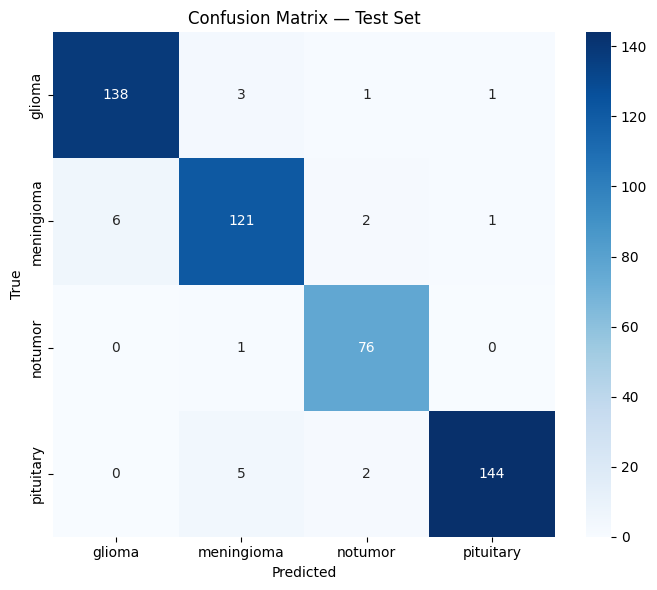

In [15]:
plt.figure(figsize=(7, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout(); plt.show()

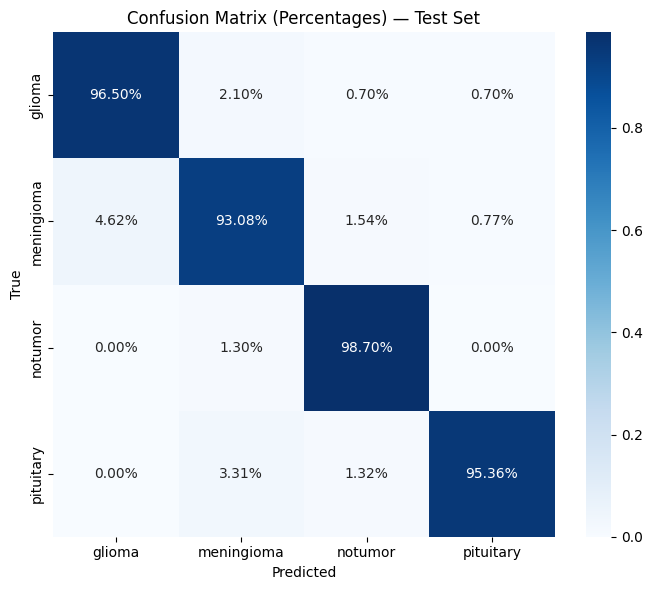

In [16]:
cm = confusion_matrix(y_true, y_pred)

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7, 6))
sns.heatmap(cm_percent, annot=True, fmt='.2%',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix (Percentages) — Test Set")
plt.tight_layout(); plt.show()

## 12. Training Curve

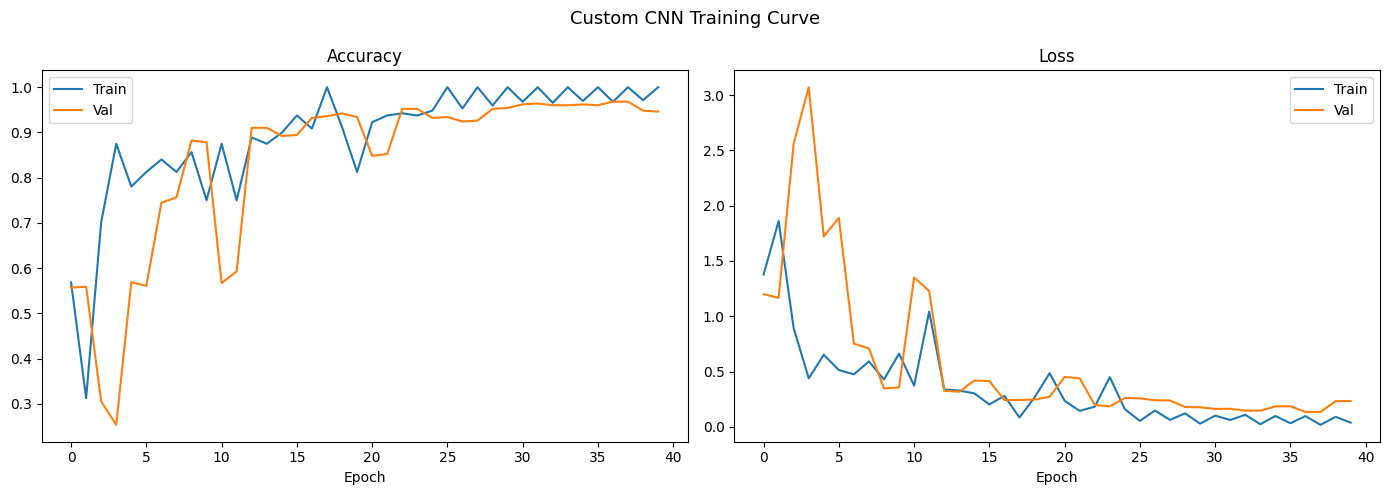


Model saved to: /kaggle/working/best_custom_cnn_improved.keras


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.suptitle('Custom CNN Training Curve', fontsize=13)
plt.tight_layout(); plt.show()

print(f"\nModel saved to: {MODEL_SAVE}")

## 13. Integrated Gradients

In [18]:
import io, cv2, base64, threading
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf

### A. Integrated Gradients

In [19]:
def compute_integrated_gradients(model, image, target_class, steps=50):
    # Baseline = black image (absence of information)
    baseline = tf.zeros((1, *image.shape), dtype=tf.float32)
    image_f = tf.cast(image[np.newaxis], tf.float32)

    # Create interpolated images from baseline (α=0) to input (α=1)
    alphas = tf.linspace(0.0, 1.0, steps + 1)[:, None, None, None]
    interpolated = baseline + alphas * (image_f - baseline)

    # Compute gradients of target class probability w.r.t interpolated images
    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        probs = tf.nn.softmax(model(interpolated, training=False), axis=-1)
        target_probs = probs[:, target_class]
    grads = tape.gradient(target_probs, interpolated)

    # Trapezoidal rule for accurate integration
    avg_grads = tf.reduce_mean((grads[:-1] + grads[1:]) / 2.0, axis=0)

    # Apply IG formula: scale gradients by (input - baseline)
    attributions = (image_f[0] - baseline[0]) * avg_grads

    # Collapse to 2D by summing absolute values across channels
    ig_sum = tf.reduce_sum(tf.abs(attributions), axis=-1).numpy()

    # Normalize to [0, 1]
    ig_map = (ig_sum - ig_sum.min()) / (ig_sum.max() - ig_sum.min() + 1e-8)
    return ig_map


def compute_ig_smoothgrad(model, image, target_class, steps=50, n_samples=10, noise_pct=0.05):
    
    noise_std = noise_pct * 255.0
    maps = []
    
    for _ in range(n_samples):
        # Add Gaussian noise to create slightly different version
        noise = np.random.normal(0, noise_std, image.shape).astype(np.float32)
        noisy_img = np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)
        maps.append(compute_integrated_gradients(model, noisy_img, target_class, steps))

    # Average all runs (noise cancels out, real signal remains)
    ig_map = np.mean(maps, axis=0)
    ig_map = (ig_map - ig_map.min()) / (ig_map.max() - ig_map.min() + 1e-8)
    return ig_map


def overlay_ig_on_image(image, ig_map, alpha=0.5):
    
    # Convert original image from BGR to RGB then normalizing
    orig_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) / 255.0
    
    # Apply 'hot' colormap to attribution map, where:
    #it maps low values (0) to black, high values (1) to white/yellow

    heatmap = cm.hot(ig_map)[:, :, :3]
    
    # Blend original image and heatmap
        # When alpha=0: shows only original MRI
        # When alpha=0.5: equal mix of MRI and heatmap
        # When alpha=1: shows only heatmap

    overlay = np.clip(orig_rgb * (1 - alpha) + heatmap * alpha, 0, 1)
    
    return overlay

### B. Visualize Correct & Misclassification

In [21]:
pred_gen      = ImageDataGenerator().flow(X_test, batch_size=BATCH_SIZE, shuffle=False)
pred_probs_all = model.predict(pred_gen)
y_pred_all    = np.argmax(pred_probs_all, axis=1)
y_true_all    = np.argmax(y_test, axis=1)

correct_mask       = y_pred_all == y_true_all
misclassified_mask = ~correct_mask

print(f"Correct:       {correct_mask.sum()} / {len(y_true_all)}")
print(f"Misclassified: {misclassified_mask.sum()} / {len(y_true_all)}")


def plot_ig_grid(indices, title, n_cols=4):
    
# Calculate grid dimensions (each image pair takes 2 columns)
    n = len(indices)
    n_rows = (n + n_cols - 1) // n_cols  # Ceiling division for partial rows
    fig, axes = plt.subplots(n_rows, n_cols * 2, 
                             figsize=(3.8 * n_cols * 2, 5 * n_rows))
    axes = np.array(axes).reshape(n_rows, n_cols * 2)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)

    # Plot each image pair
    for plot_idx, test_idx in enumerate(indices):
        # Calculate position in grid
        row = plot_idx // n_cols
        col_base = (plot_idx % n_cols) * 2  # Left column of the pair

        # Get image and predictions
        img = X_test[test_idx]
        true_label = CLASS_NAMES[y_true_all[test_idx]]
        pred_class = int(y_pred_all[test_idx])
        pred_label = CLASS_NAMES[pred_class]
        confidence = pred_probs_all[test_idx][pred_class]

        # Generate IG heatmap and overlay
        ig_map = compute_ig_smoothgrad(model, img, pred_class)
        overlay = overlay_ig_on_image(img, ig_map)
        orig_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Left subplot: Original MRI
        axes[row, col_base].imshow(orig_rgb)
        axes[row, col_base].set_title(f"True: {true_label}", fontsize=9)
        axes[row, col_base].axis('off')

        # Right subplot: IG overlay
        color = '#2a9d2a' if true_label == pred_label else '#cc2222'
        axes[row, col_base + 1].imshow(overlay)
        axes[row, col_base + 1].set_title(f"Pred: {pred_label} ({confidence:.0%})",
                                           fontsize=9, color=color)
        axes[row, col_base + 1].axis('off')

    # Hide unused subplot cells (when last row is partially filled)
    for plot_idx in range(len(indices), n_rows * n_cols):
        row = plot_idx // n_cols
        col_base = (plot_idx % n_cols) * 2
        axes[row, col_base].axis('off')
        axes[row, col_base + 1].axis('off')

    plt.tight_layout()
    plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Correct:       479 / 501
Misclassified: 22 / 501



Plotting 8 correctly classified samples...


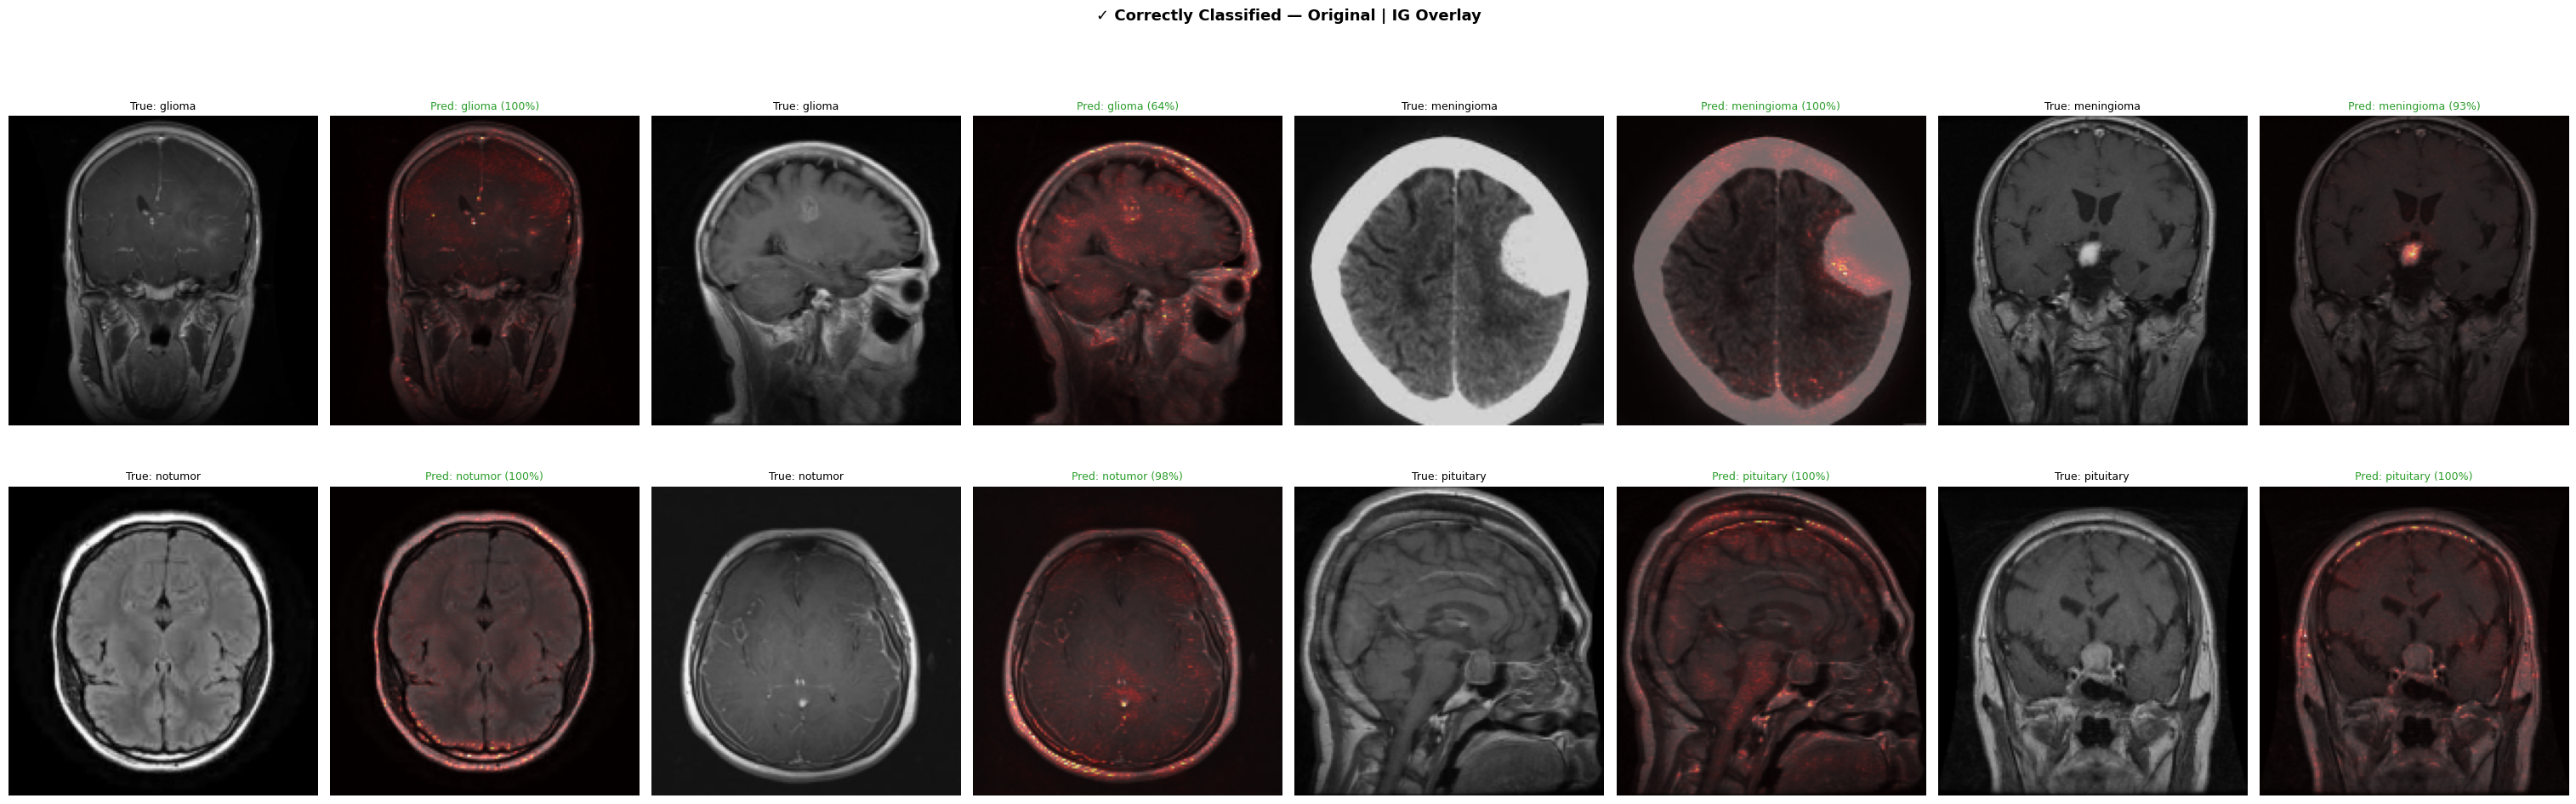


Plotting 8 misclassified samples...


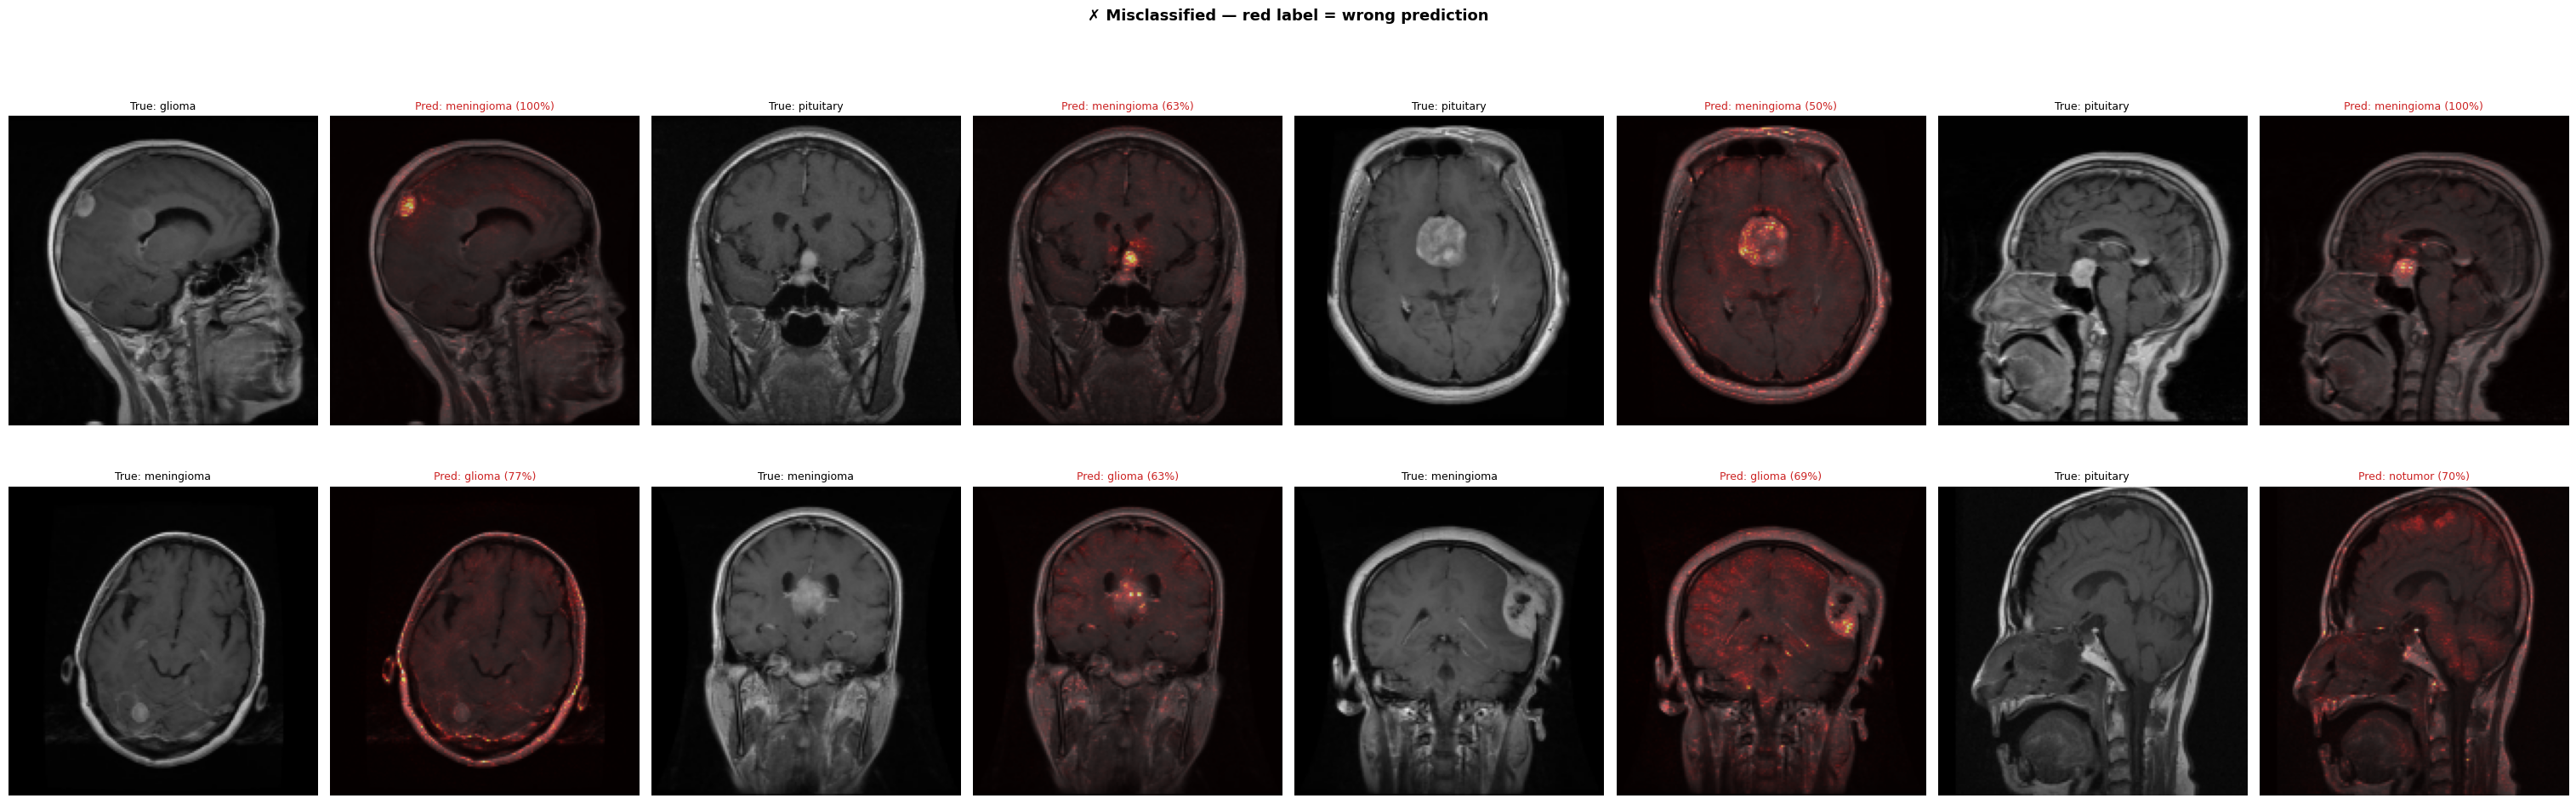

In [22]:
# Select 2 correctly classified images from each class for visualization
correct_indices = []
for cls_idx in range(len(CLASS_NAMES)):
    # Find all correctly classified images of this class
    pool = np.where(correct_mask & (y_true_all == cls_idx))[0]
    # Take 2 random samples if available
    if len(pool) >= 2:
        correct_indices.extend(np.random.choice(pool, 2, replace=False))

print(f"\nPlotting {len(correct_indices)} correctly classified samples...")
plot_ig_grid(correct_indices, "✓ Correctly Classified — Original | IG Overlay", n_cols=4)


# Visualize misclassified samples (show up to 8)
mis_indices = np.where(misclassified_mask)[0]  # Get all misclassified indices
np.random.shuffle(mis_indices)                  # Randomize for variety
n_show = min(8, len(mis_indices))               # Show max 8 samples

print(f"\nPlotting {n_show} misclassified samples...")
plot_ig_grid(
    mis_indices[:n_show],  # Take first n_show after shuffling
    "✗ Misclassified — red label = wrong prediction",
    n_cols=4
)

## 14. Website

In [23]:
!pip install -q flask flask-cors pyngrok

In [24]:
# get your own free token from (dashboard.ngrok.com):

from pyngrok import ngrok
ngrok.set_auth_token("3E4s3zCy5hhxRyc5OpT06woWtT3_6L8YUFvSM2L13bkrz49sb")

In [25]:
HTML_PAGE = """<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8"/>
  <meta name="viewport" content="width=device-width, initial-scale=1.0"/>
  <title>NeuroScan</title>
  <link href="https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=DM+Sans:ital,wght@0,300;0,400;0,500;1,300" rel="stylesheet"/>
  <style>
    *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }
    :root {
      --bg:      #060910;
      --surface: #0d1520;
      --border:  #1a2535;
      --accent:  #00d4ff;
      --accent2: #7b61ff;
      --text:    #e2e8f0;
      --muted:   #4a6080;
      --success: #00e5a0;
      --warn:    #ffb800;
      --mono:    'Space Mono', monospace;
      --sans:    'DM Sans', sans-serif;
    }
    body {
      font-family: var(--sans);
      background: var(--bg);
      color: var(--text);
      min-height: 100vh;
      display: flex;
      flex-direction: column;
      align-items: center;
      padding: 48px 20px 80px;
      background-image:
        linear-gradient(rgba(0,212,255,0.025) 1px, transparent 1px),
        linear-gradient(90deg, rgba(0,212,255,0.025) 1px, transparent 1px);
      background-size: 40px 40px;
    }
    header { text-align: center; margin-bottom: 52px; }
    .logo {
      display: inline-flex; align-items: center; gap: 10px;
      margin-bottom: 10px;
    }
    .logo-pulse {
      width: 9px; height: 9px; border-radius: 50%;
      background: var(--accent);
      box-shadow: 0 0 10px var(--accent);
      animation: pulse 2.2s ease-in-out infinite;
    }
    @keyframes pulse {
      0%,100% { opacity:1; transform:scale(1); }
      50%      { opacity:.4; transform:scale(.7); }
    }
    h1 {
      font-family: var(--mono);
      font-size: clamp(1.7rem, 4vw, 2.5rem);
      letter-spacing: -.5px;
    }
    h1 span { color: var(--accent); }
    header p { font-size: .88rem; color: var(--muted); margin-top: 8px; font-weight: 300; }
    .wrap { width: 100%; max-width: 760px; }
    .card {
      background: var(--surface);
      border: 1px solid var(--border);
      border-radius: 16px;
      padding: 32px;
      margin-bottom: 20px;
      position: relative;
      overflow: hidden;
    }
    .card::before {
      content:''; position:absolute; top:0; left:0; right:0; height:1px;
      background: linear-gradient(90deg, transparent, var(--accent), transparent);
      opacity:.35;
    }
    #drop-zone {
      border: 1.5px dashed var(--border);
      border-radius: 12px;
      padding: 52px 24px;
      text-align: center;
      cursor: pointer;
      transition: border-color .2s, background .2s;
    }
    #drop-zone.over { border-color: var(--accent); background: rgba(0,212,255,.04); }
    #drop-zone svg { margin-bottom: 14px; }
    .dz-title { font-family: var(--mono); font-size: .88rem; margin-bottom: 6px; }
    .dz-sub { font-size: .78rem; color: var(--muted); }
    .dz-sub span { color: var(--accent); text-decoration: underline; cursor: pointer; text-underline-offset: 3px; }
    #file-input { display: none; }
    #preview-row {
      display: none; align-items: center; gap: 16px;
      margin-top: 18px; padding: 14px 16px;
      background: rgba(0,212,255,.04);
      border: 1px solid var(--border); border-radius: 10px;
    }
    #preview-img { width:72px; height:72px; object-fit:cover; border-radius:8px; border:1px solid var(--border); }
    #preview-name { font-family:var(--mono); font-size:.82rem; }
    #preview-size { font-size:.72rem; color:var(--muted); margin-top:4px; }
    #analyze-btn {
      display: none; width: 100%; margin-top: 18px; padding: 14px;
      background: linear-gradient(135deg, var(--accent), var(--accent2));
      color: #000; border: none; border-radius: 10px;
      font-family: var(--mono); font-size: .88rem; font-weight: 700;
      letter-spacing: .06em; cursor: pointer;
      transition: opacity .2s, transform .1s;
    }
    #analyze-btn:hover:not(:disabled) { opacity:.88; transform:translateY(-1px); }
    #analyze-btn:disabled { opacity:.4; cursor:not-allowed; }
    .spinner {
      display:inline-block; width:13px; height:13px;
      border:2px solid rgba(0,0,0,.25); border-top-color:#000;
      border-radius:50%; animation:spin .7s linear infinite;
      vertical-align:middle; margin-right:8px;
    }
    @keyframes spin { to { transform:rotate(360deg); } }
    #error-box {
      display:none; margin-top:12px; padding:11px 14px;
      background:rgba(255,77,109,.1); border:1px solid rgba(255,77,109,.3);
      border-radius:8px; color:#ff4d6d; font-family:var(--mono); font-size:.82rem;
    }
    #result-card { display: none; }
    .res-class {
      font-family: var(--mono); font-size: 2rem; font-weight: 700;
      color: var(--accent); text-transform: uppercase; letter-spacing: .06em;
    }
    .res-conf { font-family:var(--mono); font-size:.72rem; color:var(--muted); margin-top:5px; }
    .res-conf strong { color:var(--success); font-size:.95rem; }
    .res-desc {
      font-size:.87rem; color:var(--muted); line-height:1.75;
      padding:13px 15px; border-left:2px solid var(--accent2);
      background:rgba(123,97,255,.05); border-radius:0 8px 8px 0;
      margin:18px 0 24px;
    }
    .sec-label {
      font-family:var(--mono); font-size:.67rem;
      letter-spacing:.12em; color:var(--muted);
      text-transform:uppercase; margin-bottom:13px;
    }
    .prob-row { display:flex; align-items:center; gap:12px; margin-bottom:9px; }
    .prob-name { width:95px; font-family:var(--mono); font-size:.76rem; text-transform:capitalize; }
    .prob-track { flex:1; height:5px; background:var(--border); border-radius:3px; overflow:hidden; }
    .prob-fill {
      height:100%; border-radius:3px; background:var(--muted);
      width:0%; transition:width .85s cubic-bezier(.16,1,.3,1);
    }
    .prob-fill.hi { background:linear-gradient(90deg,var(--accent2),var(--accent)); }
    .prob-pct { width:40px; text-align:right; font-family:var(--mono); font-size:.73rem; color:var(--muted); }
    .ig-panel { margin-top:26px; }
    #overlay-img {
      display:none; width:100%; border-radius:10px;
      border:1px solid var(--border); margin-top:10px;
    }
    .ig-legend {
      display:flex; align-items:center; gap:8px;
      margin-top:10px; font-size:.76rem; color:var(--muted);
    }
    .ig-gradient {
      width:80px; height:8px; border-radius:4px;
      background:linear-gradient(90deg,#000,#f00,#ff0,#fff);
      flex-shrink:0;
    }
    #reset-btn {
      display:none; width:100%; margin-top:14px; padding:11px;
      background:transparent; color:var(--muted);
      border:1px solid var(--border); border-radius:10px;
      font-family:var(--mono); font-size:.78rem; cursor:pointer;
      transition:border-color .2s,color .2s;
    }
    #reset-btn:hover { border-color:var(--accent); color:var(--accent); }
    footer {
      margin-top:44px; font-family:var(--mono); font-size:.67rem;
      color:var(--muted); text-align:center; letter-spacing:.07em;
    }
  </style>
</head>
<body>
<header>
  <div class="logo">
    <div class="logo-pulse"></div>
    <h1>Neuro<span>Scan</span></h1>
    <div class="logo-pulse"></div>
  </div>
  <p>Upload a brain MRI &mdash; get classification + integrated gradients explanation</p>
</header>
<div class="wrap">
  <div class="card">
    <div id="drop-zone">
      <svg width="34" height="34" viewBox="0 0 24 24" fill="none"
           stroke="rgba(0,212,255,.45)" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round">
        <path d="M21 15v4a2 2 0 0 1-2 2H5a2 2 0 0 1-2-2v-4"/>
        <polyline points="17 8 12 3 7 8"/><line x1="12" y1="3" x2="12" y2="15"/>
      </svg>
      <p class="dz-title">Drop your MRI image here</p>
      <p class="dz-sub">or <span id="browse">browse files</span> &nbsp;&middot;&nbsp; JPG &middot; PNG &middot; BMP</p>
      <input type="file" id="file-input" accept="image/*"/>
    </div>
    <div id="preview-row">
      <img id="preview-img" alt="preview"/>
      <div><div id="preview-name"></div><div id="preview-size"></div></div>
    </div>
    <button id="analyze-btn">ANALYZE SCAN</button>
    <div id="error-box"></div>
  </div>
  <div class="card" id="result-card">
    <div class="res-class" id="res-class">—</div>
    <div class="res-conf">CONFIDENCE &nbsp;<strong id="res-conf">—</strong></div>
    <div class="res-desc" id="res-desc">—</div>
    <div class="sec-label">Class probabilities</div>
    <div id="prob-bars"></div>
    <div class="ig-panel">
      <div class="sec-label">Integrated gradients — pixel attribution</div>
      <img id="overlay-img" alt="IG overlay"/>
      <div class="ig-legend">
        <div class="ig-gradient"></div>
        <span>dark = low attribution &nbsp;&rarr;&nbsp; white/yellow = high attribution (most influential pixels)</span>
      </div>
    </div>
    <button id="reset-btn">&#8592; ANALYZE ANOTHER SCAN</button>
  </div>
</div>
<footer>FOR RESEARCH &amp; EDUCATIONAL USE ONLY &nbsp;&middot;&nbsp; NOT A MEDICAL DIAGNOSTIC TOOL</footer>
<script>
  const $ = id => document.getElementById(id);
  const dz = $('drop-zone'), fi = $('file-input');
  let file = null;
  $('browse').onclick = () => fi.click();
  dz.onclick = e => { if (e.target !== $('browse')) fi.click(); };
  dz.addEventListener('dragover',  e => { e.preventDefault(); dz.classList.add('over'); });
  dz.addEventListener('dragleave', () => dz.classList.remove('over'));
  dz.addEventListener('drop',      e => { e.preventDefault(); dz.classList.remove('over'); pick(e.dataTransfer.files[0]); });
  fi.addEventListener('change',    () => pick(fi.files[0]));
  function pick(f) {
    file = f;
    const r = new FileReader();
    r.onload = e => {
      $('preview-img').src = e.target.result;
      $('preview-name').textContent = f.name;
      $('preview-size').textContent = (f.size/1024).toFixed(1)+' KB';
      $('preview-row').style.display  = 'flex';
      $('analyze-btn').style.display  = 'block';
      $('error-box').style.display    = 'none';
      $('result-card').style.display  = 'none';
    };
    r.readAsDataURL(f);
  }
  $('analyze-btn').addEventListener('click', async () => {
    if (!file) return;
    const btn = $('analyze-btn');
    btn.disabled = true;
    btn.innerHTML = '<span class="spinner"></span>ANALYZING\u2026';
    $('error-box').style.display = 'none';
    const fd = new FormData();
    fd.append('file', file);
    try {
      const res  = await fetch('/predict', { method:'POST', body:fd });
      const data = await res.json();
      if (!res.ok) throw new Error(data.error || 'Server error');
      render(data);
    } catch(e) {
      $('error-box').textContent    = 'Error: ' + e.message;
      $('error-box').style.display  = 'block';
    } finally {
      btn.disabled  = false;
      btn.innerHTML = 'ANALYZE SCAN';
    }
  });
  function render(d) {
    $('res-class').textContent = d.prediction.toUpperCase();
    $('res-conf').textContent  = (d.confidence*100).toFixed(1)+'%';
    $('res-desc').textContent  = d.description;
    const bars = $('prob-bars');
    bars.innerHTML = '';
    Object.entries(d.probabilities)
      .sort((a,b) => b[1]-a[1])
      .forEach(([cls,p],i) => {
        const pct = (p*100).toFixed(1);
        bars.innerHTML += `
          <div class="prob-row">
            <span class="prob-name">${cls}</span>
            <div class="prob-track"><div class="prob-fill ${i===0?'hi':''}" data-w="${pct}%"></div></div>
            <span class="prob-pct">${pct}%</span>
          </div>`;
      });
    requestAnimationFrame(() => requestAnimationFrame(() => {
      document.querySelectorAll('.prob-fill').forEach(el => el.style.width = el.dataset.w);
    }));
    const oi = $('overlay-img');
    oi.src          = 'data:image/png;base64,' + d.overlay_b64;
    oi.style.display = 'block';
    $('result-card').style.display = 'block';
    $('reset-btn').style.display   = 'block';
    $('result-card').scrollIntoView({ behavior:'smooth' });
  }
  $('reset-btn').addEventListener('click', () => {
    file = null; fi.value = '';
    $('preview-row').style.display  = 'none';
    $('analyze-btn').style.display  = 'none';
    $('result-card').style.display  = 'none';
    $('reset-btn').style.display    = 'none';
    $('error-box').style.display    = 'none';
    window.scrollTo({top:0, behavior:'smooth'});
  });
</script>
</body>
</html>"""

In [26]:
# ── build the 3-panel overlay image ──
def build_overlay_b64(image, ig_map, display_size=(280, 280)):
    """
    Create a 3-panel figure as base64 PNG for HTML embedding:
        [Original MRI] [IG Heatmap] [Blended Overlay]
    
    Returns: base64 string ready for <img src="data:image/png;base64,...">
    """
    # Resize both image and heatmap to consistent display size
    img_disp = cv2.resize(image, display_size, interpolation=cv2.INTER_AREA)
    ig_disp = cv2.resize(ig_map, display_size, interpolation=cv2.INTER_LINEAR)

    # Prepare RGB image (BGR → RGB, normalize to [0,1])
    orig_rgb = cv2.cvtColor(img_disp, cv2.COLOR_BGR2RGB) / 255.0
    
    # Apply 'hot' colormap to attribution map
    heatmap = cm.hot(ig_disp)[:, :, :3]
    
    # Blend: 50% original, 50% heatmap
    overlay = np.clip(orig_rgb * 0.5 + heatmap * 0.5, 0, 1)

    # Create 3-panel figure
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.patch.set_facecolor('#0d1117')  # Dark background for web

    # Define each panel: (title, image, colormap)
    panels = [
        ('Original MRI', orig_rgb, 'gray'),
        ('Attribution map', ig_disp, 'hot'),
        ('Overlay', overlay, None)
    ]
    
    for ax, (title, img, cmap) in zip(axes, panels):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, color='white', fontsize=9, pad=7)
        ax.axis('off')

    # Save to PNG in memory
    plt.tight_layout(pad=1.5)
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
    plt.close(fig)
    buf.seek(0)
    
    return base64.b64encode(buf.read()).decode('utf-8')

In [27]:
# ── Flask app factory for web deployment ──────────────────────────────────────────
def run_flask_app(model, class_names, class_info, img_size):
    """
    Starts Flask inside Colab and exposes it publicly via ngrok.

    Usage:
        url = run_flask_app(model, CLASS_NAMES, CLASS_INFO, IMG_SIZE)
    """
    from flask import Flask, request, jsonify, Response
    from flask_cors import CORS
    from pyngrok import ngrok

    app = Flask(__name__)
    CORS(app)  # Allow cross-origin requests from web browser

    # Serve the HTML page
    @app.route('/')
    def index():
        return Response(HTML_PAGE, mimetype='text/html')

    # Handle image upload and prediction
    @app.route('/predict', methods=['POST'])
    def predict():
        # Validate file upload
        if 'file' not in request.files:
            return jsonify({'error': 'No file provided'}), 400
        
        # Decode uploaded image
        file_bytes = np.frombuffer(request.files['file'].read(), np.uint8)
        img_bgr = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
        if img_bgr is None:
            return jsonify({'error': 'Could not decode image'}), 400

        # Apply same preprocessing as training
        img = preprocess_brain_mri_array(img_bgr, img_size)
        if img is None:
            return jsonify({'error': 'Could not preprocess image'}), 400

        # Run inference
        probs = tf.nn.softmax(
            model(tf.cast(img[np.newaxis], tf.float32), training=False), axis=-1
        )[0].numpy()
        pred_class = int(np.argmax(probs))
        confidence = float(probs[pred_class])

        # Generate Integrated Gradients visualization
        ig_map = compute_integrated_gradients(model, img, pred_class)
        overlay_b64 = build_overlay_b64(img, ig_map)

        # Return JSON response for frontend
        return jsonify({
            'prediction': class_names[pred_class],
            'confidence': round(confidence, 4),
            'probabilities': {class_names[i]: round(float(probs[i]), 4)
                              for i in range(len(class_names))},
            'description': class_info[class_names[pred_class]],
            'overlay_b64': overlay_b64,
        })

    # Setup ngrok tunnel for public access
    ngrok.kill()  # Kill any existing tunnels
    public_url = ngrok.connect(5000)
    print(f"\n{'━'*52}")
    print(f"  NeuroScan live at → {public_url}")
    print(f"  Open the URL above in any browser")
    print(f"  Ctrl+C in the cell output to stop")
    print(f"{'━'*52}\n")

    # Run Flask in background thread (non-blocking for Colab)
    t = threading.Thread(
        target=lambda: app.run(host='0.0.0.0', port=5000, use_reloader=False)
    )
    t.daemon = True
    t.start()
    
    return public_url

In [28]:
# Launching the web app

CLASS_INFO = {
    'glioma':      'Arises from glial cells. Ranges from slow-growing (grade I) to aggressive glioblastoma (grade IV).',
    'meningioma':  'Grows on the meninges (brain lining). Usually benign and slow-growing.',
    'notumor':     'No tumor detected in this scan.',
    'pituitary':   'Forms on the pituitary gland. Usually benign but can affect hormone levels.',
}

url = run_flask_app(model, CLASS_NAMES, CLASS_INFO, IMG_SIZE)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  NeuroScan live at → NgrokTunnel: "https://liable-peso-docile.ngrok-free.dev" -> "http://localhost:5000"
  Open the URL above in any browser
  Ctrl+C in the cell output to stop
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.19.2.2:5000
Press CTRL+C to quit
127.0.0.1 - - [28/May/2026 19:43:20] "GET / HTTP/1.1" 200 -
